# Social Media Dataset Exploration

This notebook explores the social media dataset collected from multiple platforms.


In [1]:
import json
import os
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from tqdm.auto import tqdm

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)

d:\Projects\sentiment-analysis-socialmedia\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATASET_DIR = Path("../Dataset/merged")

files = sorted(DATASET_DIR.glob("*.jsonl"))

print("Merged files:", len(files))

files

Merged files: 11


[WindowsPath('../Dataset/merged/1.jsonl'),
 WindowsPath('../Dataset/merged/10.jsonl'),
 WindowsPath('../Dataset/merged/11.jsonl'),
 WindowsPath('../Dataset/merged/2.jsonl'),
 WindowsPath('../Dataset/merged/3.jsonl'),
 WindowsPath('../Dataset/merged/4.jsonl'),
 WindowsPath('../Dataset/merged/5.jsonl'),
 WindowsPath('../Dataset/merged/6.jsonl'),
 WindowsPath('../Dataset/merged/7.jsonl'),
 WindowsPath('../Dataset/merged/8.jsonl'),
 WindowsPath('../Dataset/merged/9.jsonl')]

In [3]:
dfs = []

for file in tqdm(files):
    dfs.append(
        pd.read_json(file, lines=True)
    )

social_df = pd.concat(
    dfs,
    ignore_index=True
)

print("Rows:", len(social_df))
print("Columns:", len(social_df.columns))

100%|██████████| 11/11 [07:52<00:00, 42.97s/it]


Rows: 19508046
Columns: 20


In [4]:
social_df.head()

,post_id,user_id,instance,date,text,langs,like_count,reply_count,repost_count,reply_to,replied_author,thread_root,thread_root_author,repost_from,reposted_author,quotes,quoted_author,labels,sent_label,sent_score
0,147967305,1000000,bsky.social,1976-05-31 15:06:22.239,おはようございます！,[jpn],0,0,0,1281432.0,82853.0,1281432.0,82853.0,NaN,NaN,NaN,NaN,None,NaN,NaN
1,147967306,1000000,bsky.social,1976-05-31 15:05:52.304,おはようございます！,[jpn],0,0,0,1281434.0,82853.0,1281434.0,82853.0,NaN,NaN,NaN,NaN,None,NaN,NaN
2,147967307,1000000,bsky.social,1976-05-31 15:05:51.253,気になります。食べてみたい。,[jpn],0,0,0,65806585.0,82853.0,65806585.0,82853.0,NaN,NaN,NaN,NaN,None,NaN,NaN
3,147967308,1000000,bsky.social,1976-05-31 15:05:42.250,おはようございます！,[jpn],0,0,0,1281436.0,82853.0,1281436.0,82853.0,NaN,NaN,NaN,NaN,None,NaN,NaN
4,147967309,1000000,bsky.social,1976-05-31 15:05:22.255,おはようございます！,[jpn],0,0,0,1281440.0,82853.0,1281440.0,82853.0,NaN,NaN,NaN,NaN,None,NaN,NaN


In [5]:
social_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19508046 entries, 0 to 19508045
Data columns (total 20 columns):
 #   Column              Dtype         
---  ------              -----         
 0   post_id             int64         
 1   user_id             int64         
 2   instance            str           
 3   date                datetime64[ms]
 4   text                str           
 5   langs               object        
 6   like_count          int64         
 7   reply_count         int64         
 8   repost_count        int64         
 9   reply_to            float64       
 10  replied_author      float64       
 11  thread_root         float64       
 12  thread_root_author  float64       
 13  repost_from         float64       
 14  reposted_author     float64       
 15  quotes              float64       
 16  quoted_author       float64       
 17  labels              object        
 18  sent_label          float64       
 19  sent_score          float64       
dtypes: datetime

In [6]:
missing = pd.DataFrame({
    "Missing": social_df.isna().sum(),
    "Percent": social_df.isna().mean()*100
})

missing.sort_values("Percent", ascending=False)

,Missing,Percent
labels,19184403,98.340977
quotes,18515432,94.911771
quoted_author,18515432,94.911771
repost_from,14278554,73.193153
reposted_author,14278554,73.193153
replied_author,12192025,62.497418
reply_to,12192025,62.497418
thread_root,12192025,62.497418
thread_root_author,12192025,62.497418
sent_label,9368930,48.025979


In [8]:
numeric_cols = social_df.select_dtypes(include=["number"])

numeric_cols.describe().T

,count,mean,std,min,25%,50%,75%,max
post_id,19508046.0,1.168840e+08,6.814568e+07,6.000,5.758949e+07,1.178433e+08,1.755218e+08,2.341398e+08
user_id,19508046.0,5.140249e+05,6.589887e+05,9.000,7.672900e+04,2.664600e+05,6.751340e+05,4.099627e+06
like_count,19508046.0,1.053663e+02,7.634344e+02,0.000,1.000000e+00,2.000000e+00,1.200000e+01,4.192100e+04
reply_count,19508046.0,2.755748e+00,1.657562e+01,0.000,0.000000e+00,0.000000e+00,1.000000e+00,4.391000e+03
repost_count,19508046.0,3.215207e+01,3.079275e+02,0.000,0.000000e+00,0.000000e+00,2.000000e+00,1.971300e+04
reply_to,7316021.0,7.242109e+07,6.020739e+07,14.000,2.034638e+07,5.752701e+07,1.155767e+08,2.341377e+08
replied_author,7316021.0,3.108417e+05,4.803133e+05,0.000,3.681400e+04,1.377280e+05,3.702310e+05,4.410224e+06
thread_root,7316021.0,5.165453e+07,5.349327e+07,14.000,9.025455e+06,3.277515e+07,7.871760e+07,2.341377e+08
thread_root_author,7316021.0,2.675444e+05,4.484705e+05,1.000,3.029700e+04,1.010980e+05,3.057590e+05,4.410224e+06
repost_from,5229492.0,2.812008e+07,3.956951e+07,9.000,2.197499e+06,1.060374e+07,3.789276e+07,2.340005e+08


In [9]:
text_cols = social_df.select_dtypes(include=["object", "string"])

text_cols.columns

Index(['instance', 'text', 'langs', 'labels'], dtype='str')

In [10]:
for col in text_cols.columns:
    print(f"\n{col}")
    print("Missing :", social_df[col].isna().sum())
    print("Examples:")
    print(social_df[col].dropna().head(3).tolist())


instance
Missing : 0
Examples:
['bsky.social', 'bsky.social', 'bsky.social']

text
Missing : 0
Examples:
['おはようございます！', 'おはようございます！', '気になります。食べてみたい。']

langs
Missing : 1277303
Examples:
[['jpn'], ['jpn'], ['jpn']]

labels
Missing : 19184403
Examples:
[['porn'], ['porn'], ['porn']]


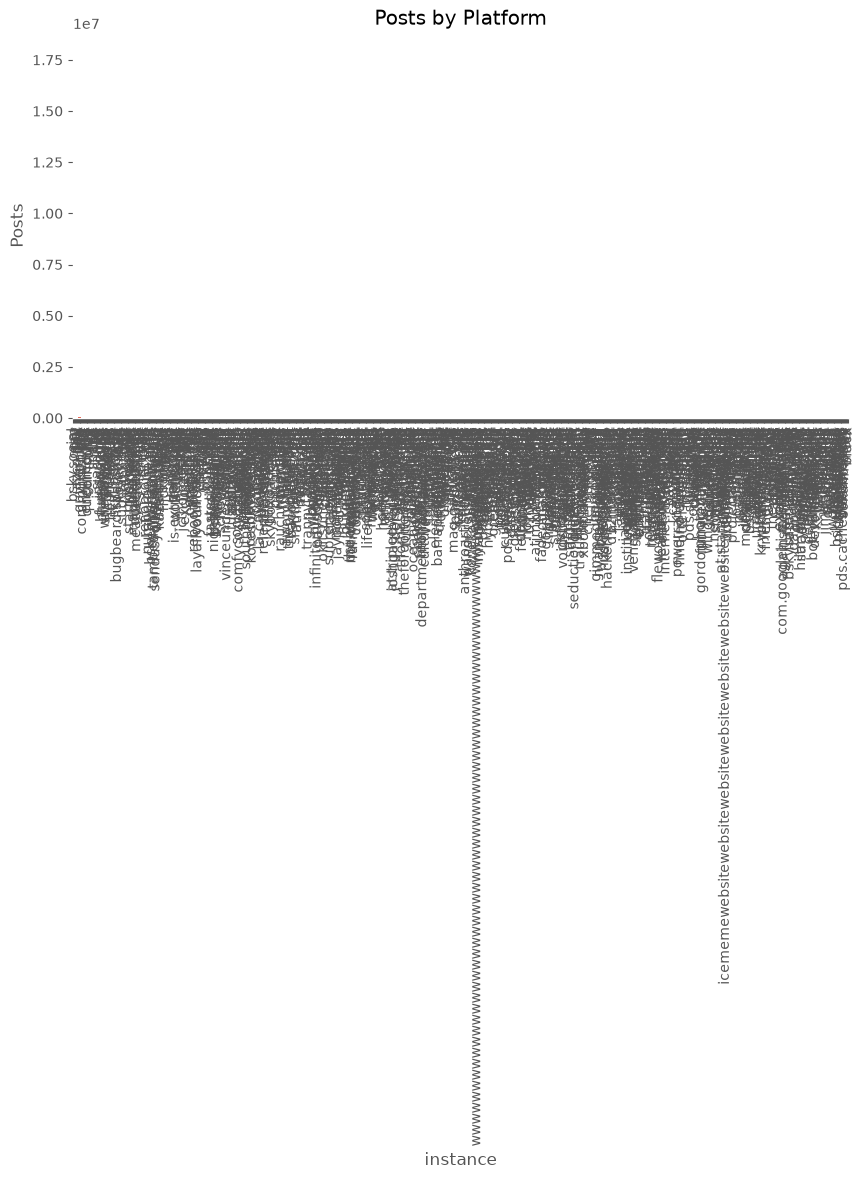

In [11]:
social_df["instance"].value_counts().plot(
    kind="bar",
    figsize=(10,5),
    title="Posts by Platform"
)

plt.ylabel("Posts")

plt.show()

In [12]:
social_df["langs"].head(20)

0     [jpn]
1     [jpn]
2     [jpn]
3     [jpn]
4     [jpn]
5     [jpn]
6     [jpn]
7     [jpn]
8     [jpn]
9     [jpn]
10    [jpn]
11    [jpn]
12    [jpn]
13    [jpn]
14    [jpn]
15    [jpn]
16    [jpn]
17    [jpn]
18    [jpn]
19    [jpn]
Name: langs, dtype: object

In [13]:
from collections import Counter

counter = Counter()

for langs in social_df["langs"].dropna():
    counter.update(langs)

lang_df = pd.DataFrame(
    counter.items(),
    columns=["Language","Count"]
).sort_values(
    "Count",
    ascending=False
)

lang_df.head(20)

,Language,Count
1,eng,10994963
0,jpn,2772641
2,deu,2149779
6,spa,526896
3,fra,521355
13,por,388102
12,kor,340192
9,nld,282527
11,ukr,171524
14,tur,112230


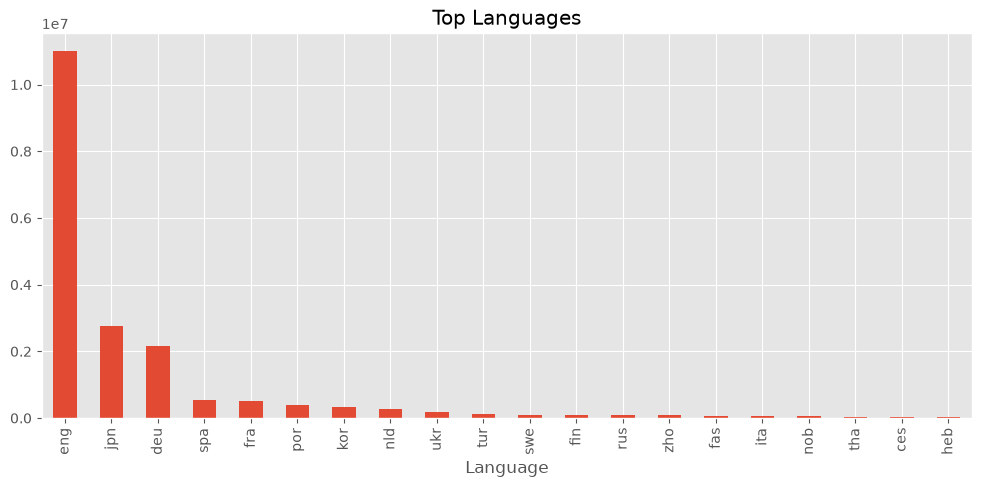

In [14]:
lang_df.head(20).plot(
    x="Language",
    y="Count",
    kind="bar",
    figsize=(12,5),
    legend=False,
    title="Top Languages"
)

plt.show()

In [15]:
social_df["sent_label"].value_counts(dropna=False)

sent_label
NaN    9368930
1.0    4115093
2.0    3319149
0.0    2704874
Name: count, dtype: int64

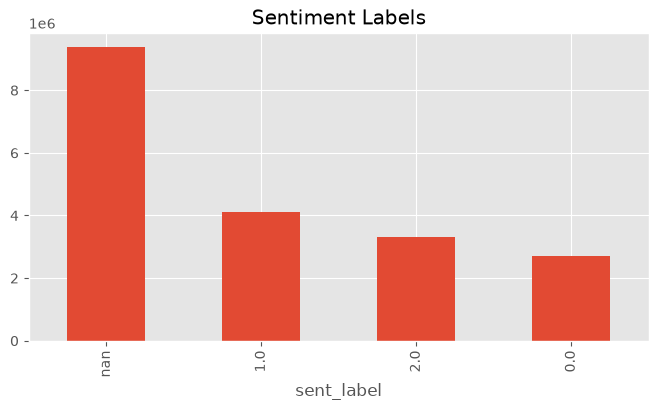

In [16]:
social_df["sent_label"].value_counts(
    dropna=False
).plot(
    kind="bar",
    figsize=(8,4),
    title="Sentiment Labels"
)

plt.show()

In [17]:
social_df["sent_score"].describe()

count    1.013912e+07
mean     7.551631e-01
std      1.573449e-01
min      3.330000e-01
25%      6.260000e-01
50%      7.750000e-01
75%      8.920000e-01
max      9.940000e-01
Name: sent_score, dtype: float64

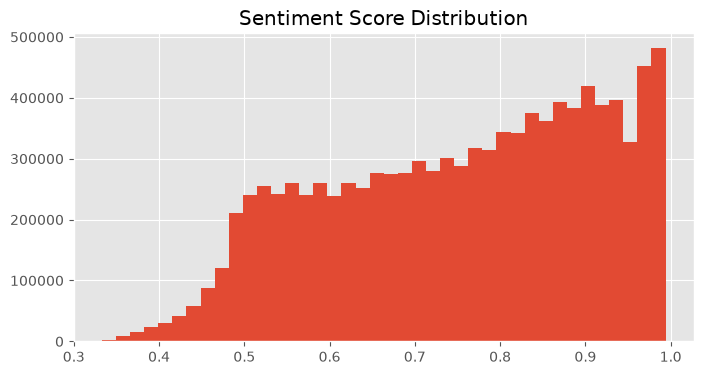

In [18]:
social_df["sent_score"].hist(
    bins=40,
    figsize=(8,4)
)

plt.title("Sentiment Score Distribution")

plt.show()

In [19]:
engagement_cols = [
    "like_count",
    "reply_count",
    "repost_count"
]

social_df[engagement_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
like_count,19508046.0,105.366306,763.434377,0.0,1.0,2.0,12.0,41921.0
reply_count,19508046.0,2.755748,16.575620,0.0,0.0,0.0,1.0,4391.0
repost_count,19508046.0,32.152072,307.927462,0.0,0.0,0.0,2.0,19713.0


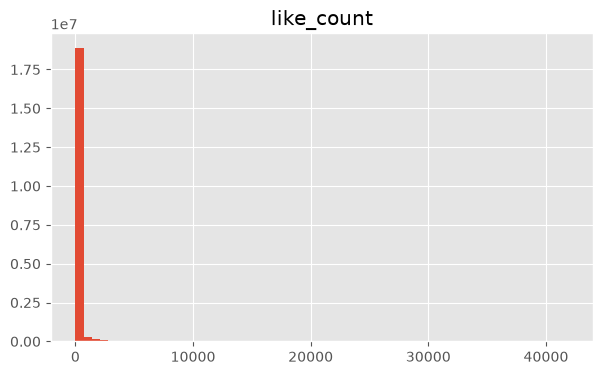

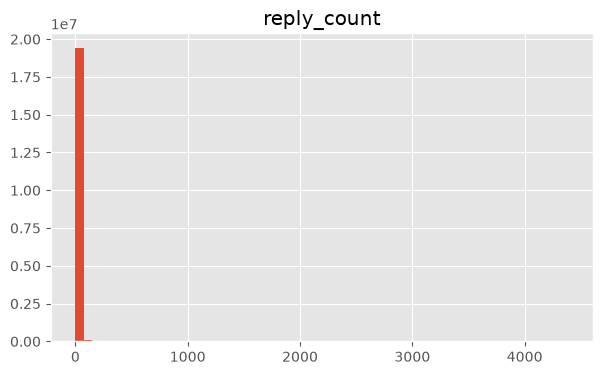

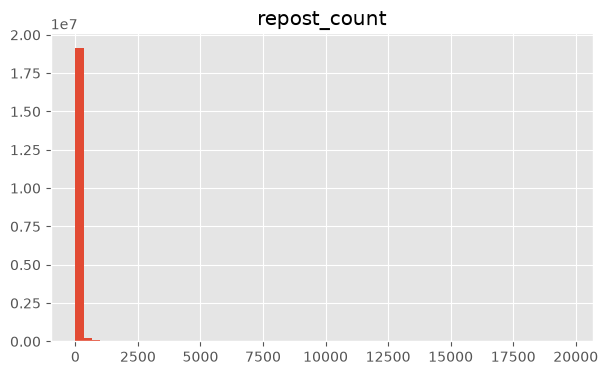

In [20]:
for col in engagement_cols:

    plt.figure(figsize=(7,4))

    social_df[col].hist(
        bins=60
    )

    plt.title(col)

    plt.show()

In [22]:
social_df["text_length"] = social_df["text"].str.len()

In [23]:
social_df["text_length"].describe()

count    1.950805e+07
mean     9.117556e+01
std      8.557056e+01
min      0.000000e+00
25%      2.400000e+01
50%      6.000000e+01
75%      1.340000e+02
max      1.542000e+03
Name: text_length, dtype: float64

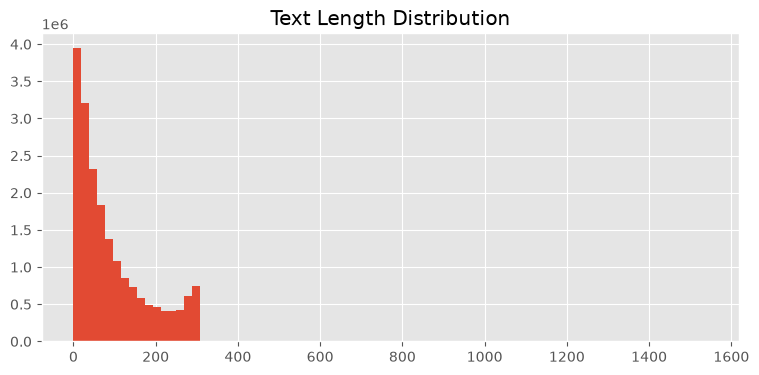

In [24]:
social_df["text_length"].hist(
    bins=80,
    figsize=(9,4)
)

plt.title("Text Length Distribution")

plt.show()

In [25]:
social_df[
    ["instance","text"]
].sample(10, random_state=42)

,instance,text
10155169,bsky.social,포항의 가속기 연구소도 예산이 없어 일부 가동 중단이라고 한다. 대부분 국가 연구소의 연구원들 중 무기계약이 많은데 내년에 전원 재계약 않겠다고 벌써부터 통보한 곳도 있다고. \n\n기초과학이 얼마나 중요한데 그마나 닦아 놓은 것도 다 없애려 햐나. 이런 연구...
3450125,bsky.social,Have you considered pinning the NYC feed? \n\nhttps://bsky.app/profile/did:plc:nb3fnt2yrtnasyh6fjocbayt/feed/aaafnsrzq3sus
3174379,bsky.social,this will kill a lot of women. a lot
6169030,bsky.social,🤗
16975436,bsky.social,5555555 ความคิดดี
15599863,bsky.social,Jack: The device needs to connect all senses in the perceptible zones of our awareness while in the now in a purely authentic manner and transmit ...
18061253,bsky.social,Who would vote for that? 30% of Americans? More than 30%? I thought it was only 6-10% (really fascist) but am not so sure now.
8043140,bsky.social,"Lol, am I really the first person to notice that?"
14227368,bsky.social,コラボカフェたのしみーらくがき
1841763,bsky.social,reading my children Nate Silver's tweets this morning before they can open presents; they're crying and flailing but they need to know this


In [26]:
social_df[
    ["text","sent_label","sent_score"]
].sample(20, random_state=7)

,text,sent_label,sent_score
9874115,Temporal,1.0,0.760
13543064,Your first five? So good!,2.0,0.982
821941,"There is something cooking on the stove. It smells good. As long as it's on the stove, this is where I'll be",2.0,0.955
16453937,It doesn't get much better than duck fat potatoes.,0.0,0.622
467625,"""NOBODY WANTS TO WORK ANY MORE!""\n\nA brief history of capitalists complaining that nobody wants to work for starvation wages",0.0,0.854
2315575,It goes on like this for another page y'all are commanding the dialogue,1.0,0.749
17318973,"Hey! I got a big ol' bundle of art that YOU can use in your TTRPG modules, livestreams, VODs, or whatever you like, royalty free for just £25! Inc...",2.0,0.950
9802162,新人ボカロPです\n古参になりませんか？\n\n作詞作曲編曲\nイラストアニメーション動画編集\n全て1人で行ってます！\n\nリスナーさんもPさんも絵師さんも動画師さんも仲良くしましょ〜\n\n▼「波際の方程式」\nボカコレ2023夏ルーキー\n参加楽曲です 聴いてみてね\n\nyoutu...,NaN,NaN
10053521,OK if the image detection AI on here can detect whether someone is showing two inches of cleavage then it can detect when a screenshot has the wor...,1.0,0.743
15131132,For my Eme lovers~ she's grown to like having her nuts stretched 😏,2.0,0.767
